In [1]:
"""Cluster Latent Space

Structure:
    1.1. Imports, Variables, Functions
    1.2. Load Data
"""

# 1.1 Imports, Variables, Functions
# imports
import sys

sys.path.append("exp/utils_exp")
from utils_exp import utils as ut
import pandas as pd, numpy as np, os, sys
import anndata as ad
import logging
from typing import *
import pickle
import matplotlib.pyplot as plt
import seaborn as sns
import json
from sklearn.metrics import (
    roc_auc_score,
    roc_curve,
    auc,
    precision_recall_curve,
    average_precision_score,
)
from sklearn.metrics import confusion_matrix, classification_report
import sys

sys.path.append(os.path.join("..", ".."))
# # from src.utils import utils as ut
from src.utils import viz as vz
from src.utils import io

logging.basicConfig(level=logging.INFO)
import importlib
import scanpy as sc
from src.utils import utils

importlib.reload(ut)
importlib.reload(vz)


# variables
# run_dir = os.path.join("..","..","outputs","run-25-09-28-05")
run_dir = os.path.join("..", "..", "outputs", "run-25-09-13-18")  # RNA-seq
# run_dir = os.path.join("..","..","outputs","run-25-10-05-01")
# run_dir = os.path.join("..","..","outputs","run-25-09-17-01") # Microarray

embedding_type = "raw"
metric = "correlation"  # cosine or correlation

assert embedding_type in ["ft", "pt", "raw", "raw_normed"]
if embedding_type == "ft":
    run_name = run_dir.split("/")[-1]
    output_dir = os.path.join(run_dir, "outputs")
elif embedding_type == "pt":
    run_name = run_dir.split("/")[-1]
    output_dir = os.path.join(
        "/aloy/scratch/ddalton/projects/scGPT_playground/outputs/", run_name, "outputs"
    )
elif embedding_type == "raw":
    run_name = run_dir.split("/")[-1]
    output_dir = os.path.join(
        "/aloy/scratch/ddalton/projects/scGPT_playground/outputs/", run_name, "outputs"
    )


# functions
def get_counts(df: pd.DataFrame, rel_map: Dict, key_interest: str) -> pd.DataFrame:
    df_query = df.copy()

    n_same, n_rel, n_unrel, n_total, n_universe_related, n_total_unique = (
        [],
        [],
        [],
        [],
        [],
        [],
    )
    n_same_uniq, n_rel_uniq = [], []

    for _, r in df_query.iterrows():
        topk = list(r[key_interest])  # keep duplicates
        doid = r["query_doid"]
        related = rel_map.get(doid, set())

        same = sum(1 for x in topk if x == doid)  # absolute count of the exact disease
        rel = sum(
            1 for x in topk if x in related
        )  # absolute count of related diseases (counts repeats)
        total = len(topk)
        unrel = total - same - rel

        n_same.append(same)
        n_same_uniq.append(len(set(topk) & {doid}))
        n_rel.append(rel)
        n_rel_uniq.append(len(set(topk) & related))
        n_unrel.append(unrel)
        n_total.append(total)
        n_universe_related.append(len(related) + 1)  # +1 to include self
        n_total_unique.append(len(set(topk)))

    df_query["n_same"] = n_same
    df_query["n_rel"] = n_rel
    df_query["n_unrel"] = n_unrel
    df_query["n_total"] = n_total
    df_query["n_universe_related"] = n_universe_related
    df_query["n_total_unique"] = n_total_unique
    df_query["n_same_uniq"] = n_same_uniq
    df_query["n_rel_uniq"] = n_rel_uniq

    df_query["pct_same"] = df_query["n_same"] / df_query["n_total"] * 100
    df_query["pct_rel"] = df_query["n_rel"] / df_query["n_total"] * 100
    df_query["pct_unrel"] = df_query["n_unrel"] / df_query["n_total"] * 100

    df_query["hits_same"] = (df_query["n_same"] > 0).astype(int)
    df_query["hits_rel"] = (df_query["n_rel"] > 0).astype(int)

    # get precision
    # df_query["prec@k"] = (df_query["n_rel"]+df_query["n_same"]) / df_query["n_total"]

    df_query["old_prec@k"] = (df_query["n_rel"] + df_query["n_same"]) / df_query[
        "n_total"
    ]
    df_query["old_recall@k"] = (df_query["n_rel"] + df_query["n_same"]) / df_query[
        "n_universe_related"
    ]
    df_query["prec@k"] = (df_query["n_rel_uniq"] + df_query["n_same_uniq"]) / df_query[
        "n_total_unique"
    ]
    df_query["recall@k"] = (
        df_query["n_rel_uniq"] + df_query["n_same_uniq"]
    ) / df_query["n_universe_related"]

    return df_query


# 1.2 Load Data
(
    # split,
    predictions_test,
    labels_test,
    results_test,
    all_outputs_test,
    predictions_valid,
    labels_valid,
    results_valid,
    all_outputs_valid,
    predictions_train,
    labels_train,
    results_train,
    all_outputs_train,
    adata_orig,
    id2type,
    train_indices,
    valid_indices,
) = io.load_run_output(run_dir)

# load json

with open(os.path.join(run_dir, "parameters.json"), "r") as f:
    parameters = json.load(f)

for k, v in parameters.items():
    print(f"{k}: {v}")

/aloy/home/ddalton/miniconda3/envs/scgpt/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Loaded variable predictions_test
Loaded variable labels_test
Loaded variable results_test
Loaded variable all_outputs_test
Loaded variable predictions_valid
Loaded variable labels_valid
Loaded variable results_valid
Loaded variable all_outputs_valid
Loaded variable predictions_train
Loaded variable labels_train
Loaded variable results_train
Loaded variable all_outputs_train
Loaded variable adata_orig
Loaded variable id2type
Loaded variable train_indices
Loaded variable valid_indices
Nº of loaded variables 16
data_path: /aloy/home/ddalton/projects/scGPT_playground/data/pp_data-25-09-12-01/data.h5ad
max_seq_len: 3501
batch_size: 16
gene_presence_pct: 0.9
benchmark_data: False
split_type: stratified
val_split_type: rand_stratified
n_splits: 10
n_tested_splits: 10
epochs: 50
gene_filtering: top_presence
sample_presence_pct: 0.3
MLM: False
CLS: False
CLS_multilabel: True
DAB: False
ADV: False
CCE: False
ecs_thres: 0.0
dab_weight: 0.0
use_fast_transformer: True
output_attentions: False
INPUT

In [2]:
split_idx = 0

# load all adata
adata_test = sc.read(
    os.path.join(run_dir, f"adata_test_{split_idx+1}.h5ad"), backed="r"
)
adata_test.obs.reset_index(drop=True, inplace=True)
adata_valid = sc.read(
    os.path.join(run_dir, f"adata_valid_{split_idx+1}.h5ad"), backed="r"
)
adata_valid.obs.reset_index(drop=True, inplace=True)
adata_train = sc.read(
    os.path.join(run_dir, f"adata_train_{split_idx+1}.h5ad"), backed="r"
)
adata_train.obs.reset_index(drop=True, inplace=True)

In [3]:
# load scGPT embeddings
print(f"Using {embedding_type} embeddings")
if embedding_type == "ft":
    embeddings_test = vz.merge_embeddings(all_outputs_test[split_idx])
    embeddings_valid = vz.merge_embeddings(all_outputs_valid[split_idx])
    embeddings_train = vz.merge_embeddings(all_outputs_train[split_idx])
    print(f"Loaded ft embeddings from all_outputs")
elif embedding_type == "pt":
    # pt_adata_test = sc.read(os.path.join("/aloy/scratch/ddalton/projects/scGPT_playground/outputs/",run_name,"pt_adata_test_1.h5ad"))
    # pt_adata_valid = sc.read(os.path.join("/aloy/scratch/ddalton/projects/scGPT_playground/outputs/",run_name,"pt_adata_valid_1.h5ad"))
    # pt_adata_train = sc.read(os.path.join("/aloy/scratch/ddalton/projects/scGPT_playground/outputs/",run_name,"pt_adata_train_1.h5ad"))
    # embeddings_test = pt_adata_test.obsm["X_scGPT"]
    # embeddings_valid = pt_adata_valid.obsm["X_scGPT"]
    # embeddings_train = pt_adata_train.obsm["X_scGPT"]

    embeddings_test = np.load(
        os.path.join(
            "/aloy/scratch/ddalton/projects/scGPT_playground/outputs/",
            run_name,
            "test-pt_embeddings.npy",
        )
    )
    embeddings_valid = np.load(
        os.path.join(
            "/aloy/scratch/ddalton/projects/scGPT_playground/outputs/",
            run_name,
            "valid-pt_embeddings.npy",
        )
    )
    embeddings_train = np.load(
        os.path.join(
            "/aloy/scratch/ddalton/projects/scGPT_playground/outputs/",
            run_name,
            "train-pt_embeddings.npy",
        )
    )
    print(f"Loaded pt embeddings from npy files")
elif embedding_type == "raw":
    embeddings_test = np.array(adata_test.X)
    embeddings_valid = np.array(adata_valid.X)
    embeddings_train = np.array(adata_train.X)

    # replace nans with 0
    embeddings_test = np.nan_to_num(embeddings_test, nan=0.0)
    embeddings_valid = np.nan_to_num(embeddings_valid, nan=0.0)
    embeddings_train = np.nan_to_num(embeddings_train, nan=0.0)
    print(f"Loaded raw embeddings from adata.X")

elif embedding_type == "raw_normed":
    embeddings_test = np.array(adata_test.layers["X_normed"])
    embeddings_valid = np.array(adata_valid.layers["X_normed"])
    embeddings_train = np.array(adata_train.layers["X_normed"])

    # replace nans with 0
    embeddings_test = np.nan_to_num(embeddings_test, nan=0.0)
    embeddings_valid = np.nan_to_num(embeddings_valid, nan=0.0)
    embeddings_train = np.nan_to_num(embeddings_train, nan=0.0)

    print(f"Loaded raw normalized embeddings from adata.X")

Using raw embeddings
Loaded raw embeddings from adata.X


In [4]:
# Load Disease Pairs

# Get disease IDs
d_ids = list(adata_train.obs["doid_id"].unique())

# load Disease Ontology Lin Similarity amongst pairs!
do_df_ic = utils.load_df_do_pairs()
print(f"Loaded universe of disease pairs: {do_df_ic.shape[0]}")

# Load IC based similarity
do_graph = utils.load_do_graph()
doid_to_term = {
    node: data["name"] for node, data in do_graph.nodes(data=True) if "name" in data
}

Loaded universe of disease pairs: 70442515


In [5]:
# get top 1% & 5% of values
ic_thr = np.quantile(do_df_ic["lin"].values, 0.95)
print(f"IC Threshold: {ic_thr:.3f}\tNº of pairss {len(do_df_ic.query('lin>@ic_thr'))}")

ic_thr_99 = np.quantile(do_df_ic["lin"].values, 0.99)
print(
    f"IC Threshold 99%: {ic_thr_99:.3f}\tNº of pairs {len(do_df_ic.query('lin>@ic_thr_99'))}"
)


# Filter pairs
do_df_ic_query = do_df_ic.query("do1 in @d_ids and do2 in @d_ids")
print("Nº of pairs in dataset:", do_df_ic_query.shape)

do_df_ic_query = do_df_ic.query(f"do1 in @d_ids and do2 in @d_ids and lin > {ic_thr}")
print("Nº of significant pairs in dataset (top 5% IC):", do_df_ic_query.shape)

do_df_ic_query_99 = do_df_ic.query(
    f"do1 in @d_ids and do2 in @d_ids and lin > {ic_thr_99}"
)
print("Nº of significant pairs in dataset (top 1% IC):", do_df_ic_query_99.shape)

do_df_negative_ic = do_df_ic.query(
    f"do1 in @d_ids and do2 in @d_ids and lin <= {ic_thr}"
)
print("Nº of negative pairs in dataset (outside 5%):", do_df_negative_ic.shape)

IC Threshold: 0.396	Nº of pairss 3518554
IC Threshold 99%: 0.543	Nº of pairs 704215
Nº of pairs in dataset: (7503, 8)
Nº of significant pairs in dataset (top 5% IC): (917, 8)
Nº of significant pairs in dataset (top 1% IC): (354, 8)
Nº of negative pairs in dataset (outside 5%): (6586, 8)


In [6]:
# map doid to related diseases
rel_map = {}
for thr in [0.396, 0.6, 0.8, 0.9]:
    rel_map[thr] = dict()
    _do_df = do_df_ic_query.query(f"lin >= {thr}")

    for d in d_ids:
        rel_map[thr][d] = set(_do_df.loc[_do_df["do1"] == d, "do2"]) | set(
            _do_df.loc[_do_df["do2"] == d, "do1"]
        )

In [7]:
_do_df = do_df_ic.query("do1 in @d_ids and do2 in @d_ids")

lin_map = dict()
for _,row in _do_df.iterrows():
    do1 = row["do1"]
    do2 = row["do2"]
    lin = row["lin"] 
    if do1 not in lin_map:
        lin_map[do1] = dict()
    if do2 not in lin_map:
        lin_map[do2] = dict()
    lin_map[do1][do2] = lin
    lin_map[do2][do1] = lin

In [8]:
# load embeddings
if embedding_type == "ft":
    embeddings_test = vz.merge_embeddings(all_outputs_test[split_idx])
    embeddings_valid = vz.merge_embeddings(all_outputs_valid[split_idx])
    embeddings_train = vz.merge_embeddings(all_outputs_train[split_idx])

elif embedding_type == "raw":
    embeddings_test = adata_test.X
    embeddings_valid = adata_valid.X
    embeddings_train = adata_train.X

    # replace nans with 0
    embeddings_test = np.nan_to_num(embeddings_test, nan=0.0)
    embeddings_valid = np.nan_to_num(embeddings_valid, nan=0.0)
    embeddings_train = np.nan_to_num(embeddings_train, nan=0.0)

elif embedding_type == "raw_normed":
    embeddings_test = adata_test.layers["X_normed"]
    embeddings_valid = adata_valid.layers["X_normed"]
    embeddings_train = adata_train.layers["X_normed"]

    # replace nans with 0
    embeddings_test = np.nan_to_num(embeddings_test, nan=0.0)
    embeddings_valid = np.nan_to_num(embeddings_valid, nan=0.0)
    embeddings_train = np.nan_to_num(embeddings_train, nan=0.0)



In [9]:
import obonet
import sys
sys.path.append("../../")
from src.utils import utils as u
import scanpy as sc

# load adata

# get Disease Ontology graph
do_g = u.load_do_graph()

# get sanchez IC
doid_2_ic = u.get_sanchez_ic(do_g)

#! IMPORTANT - FIX CONTROL CLASS


#! REMOVE - THIS IS A QUICK AND UGLY FIX
# only_control = True
# if only_control:
#     adata = adata[adata.obs["doid_id"] != "Control"].copy()




# get nodes
# _class_nodes = u.get_lvl1_nodes(do_g)
_class_nodes = u.get_n_lowest_ic_nodes(doid_2_ic, 50)
# benchmark class nodes - use the sames as in the single classifier benchmark
# _class_nodes = adata.obs["do_id"].unique().tolist()

# Generate multilabel vectors for level 1 nodes
Y_multilabel, _class_nodes = u.generate_multilabel_vectors(adata_train, do_g, _class_nodes)
print(f"Generated multilabel vectors for level 1 nodes with shape {Y_multilabel.shape}")

# Clean multilabel vectors by removing nodes with no samples
Y_multilabel, _class_nodes = u.clean_multilabel_vectors(Y_multilabel, _class_nodes)
print(f"Cleaned multilabel vectors for top 50 nodes with shape {Y_multilabel.shape}")

# Check the multilabel vector for level 1 nodes
u.check_multilabel_vector(Y_multilabel, _class_nodes, do_g)

# get doids and class names
Y_multilabel_doid, Y_multilabel_name = u.get_multilabel_data(Y_multilabel, _class_nodes, do_g)


Number of DO leaves: 9018
Generated multilabel vectors for level 1 nodes with shape (18305, 51)
Cleaned multilabel vectors for top 50 nodes with shape (18305, 48)
6482 samples	Node Control
364 samples	Node DOID:0014667 - disease of metabolism
217 samples	Node DOID:0050117 - disease by infectious agent
36 samples	Node DOID:0050155 - sensory system disease
190 samples	Node DOID:0050177 - monogenic disease
3817 samples	Node DOID:0050686 - organ system cancer
3641 samples	Node DOID:0050687 - cell type cancer
13 samples	Node DOID:0050735 - X-linked monogenic disease
53 samples	Node DOID:0050736 - autosomal dominant disease
88 samples	Node DOID:0050737 - autosomal recessive disease
141 samples	Node DOID:0050739 - autosomal genetic disease
3 samples	Node DOID:0060072 - benign neoplasm
3 samples	Node DOID:0060085 - organ system benign neoplasm
128 samples	Node DOID:0080000 - muscular disease
424 samples	Node DOID:0080001 - bone disease
5 samples	Node DOID:0080015 - physical disorder
213 sample

In [10]:
import numpy as np
max(np.sum(Y_multilabel, axis=1))

np.int64(9)

In [51]:
from sklearn.metrics import jaccard_score
from sklearn.metrics.pairwise import cosine_similarity

sample_size = 100000

df_train = adata_train.obs.copy()

doid_2_y = dict(zip(df_train["doid_id"].to_list(), Y_multilabel))

# sample 1k pairs of diseases
_dis_ids = df_train["doid_id"].to_numpy()
all_dis_idxs = np.argwhere(_dis_ids != "Control").flatten()
_sample_idxs = np.array([np.random.choice(all_dis_idxs, size=2, replace=False) for _ in range(sample_size)])

# get ontology similarity
ontology_s = []
for idx1, idx2 in _sample_idxs:
    doid1 = _dis_ids[idx1]
    doid2 = _dis_ids[idx2]
    if doid1 == doid2:
        ontology_s.append(1.0)
        continue
    sim = lin_map[doid1][doid2]
    ontology_s.append(sim)

# get one hot encoding similarity
one_hot_s = []
for idx1, idx2 in _sample_idxs:
    doid1 = _dis_ids[idx1]
    doid2 = _dis_ids[idx2]
    one_hot_1 = doid_2_y[doid1]
    one_hot_2 = doid_2_y[doid2]
    # sim = jaccard_score(one_hot_1, one_hot_2)
    sim = cosine_similarity([one_hot_1], [one_hot_2])[0][0]
    one_hot_s.append(sim)


In [67]:
from tqdm import tqdm
# unrelated disease pairs
_doid_pairs = do_df_negative_ic["pair_sorted"].to_list()
unr_ont_s = list()
unr_one_hot_s = list()

for d1, d2 in tqdm(_doid_pairs):

    # get ontology similarity
    unr_ont_s.append(lin_map[d1][d2])

    # get one hot encoding similarity
    one_hot_1 = doid_2_y[d1]
    one_hot_2 = doid_2_y[d2]
    unr_one_hot_s.append(jaccard_score(one_hot_1, one_hot_2))

# related disease pairs
rel_ont_s = list()
rel_one_hot_s = list()
for lin_thr in [0.396, 0.6, 0.8]:
    doid_pairs = do_df_ic_query.query(f"lin >= {lin_thr}")["pair_sorted"].to_list()
    
    ont_s = list()
    one_hot_s = list()
    for d1, d2 in tqdm(doid_pairs):
        
        # get ontology similarity
        ont_s.append(lin_map[d1][d2])

        # get one hot encoding similarity
        one_hot_1 = doid_2_y[d1]
        one_hot_2 = doid_2_y[d2]
        one_hot_s.append(jaccard_score(one_hot_1, one_hot_2))
    rel_ont_s.extend(ont_s)
    rel_one_hot_s.extend(one_hot_s)


100%|██████████| 48/48 [00:00<00:00, 2218.60it/s]


In [56]:
for lin_thr in [0.396, 0.6, 0.8]:
    
    doid_pairs = do_df_ic_query.query(f"lin >= {lin_thr}")["pair_sorted"].to_list()
    break

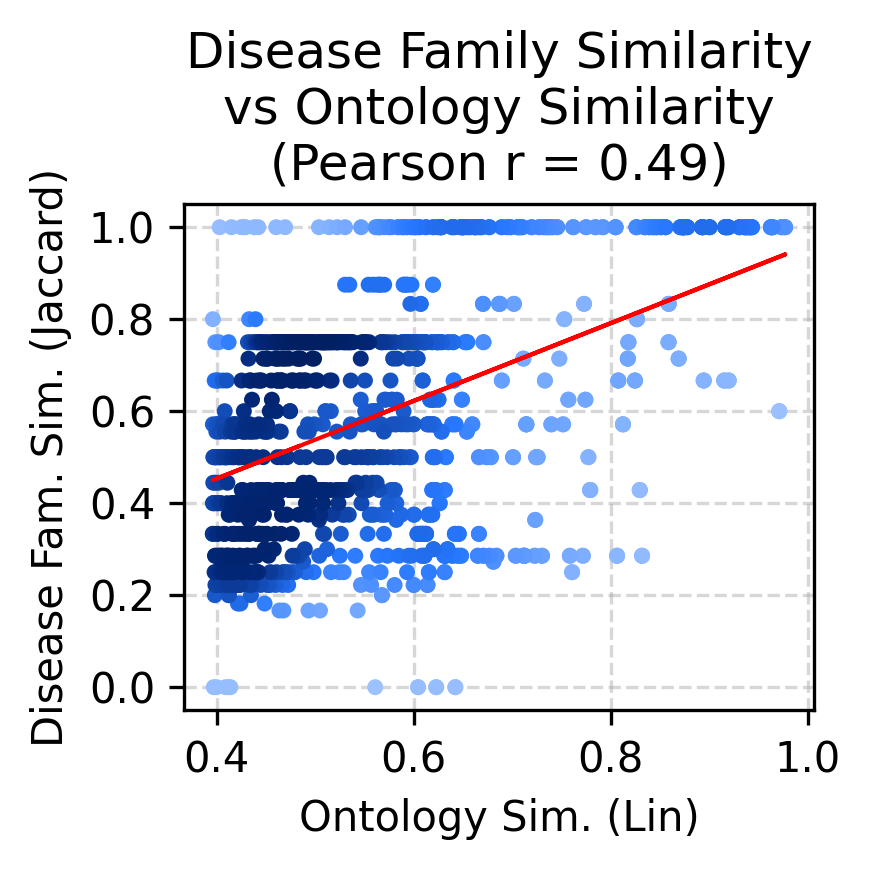

In [ ]:
from scipy.stats import gaussian_kde
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import pearsonr, spearmanr
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap


# Create colormap
custom_cmap = LinearSegmentedColormap.from_list(
    "custom_cmap",
    ["#9cc1ff", "#2778ff", "#022778","#011f60"],
)


x = np.array(rel_ont_s)
y = np.array(rel_one_hot_s)

pearson_r, pearson_p = pearsonr(x, y)

# Linear regression (least squares)
coef = np.polyfit(x, y, 1)
poly_fn = np.poly1d(coef)

xy = np.vstack([x, y])
z = gaussian_kde(xy)(xy)

idx = z.argsort()
x, y, z = x[idx], y[idx], z[idx]

plt.figure(figsize=(3, 3.25), dpi=300)
plt.scatter(x, y, c=z, s=8, zorder=2, cmap=custom_cmap)

plt.plot(x, poly_fn(x), linewidth=1, color="red")

plt.xlabel("Ontology Sim. (Lin)")
plt.ylabel("Disease Fam. Sim. (Jaccard)")

plt.title(
    f"Disease Family Similarity\nvs Ontology Similarity\n(Pearson r = {pearson_r:.2f})"
)

# plt.colorbar(label="Point density")
plt.grid(linestyle='--', alpha=0.5, zorder=-3)
plt.tight_layout()
plt.show()


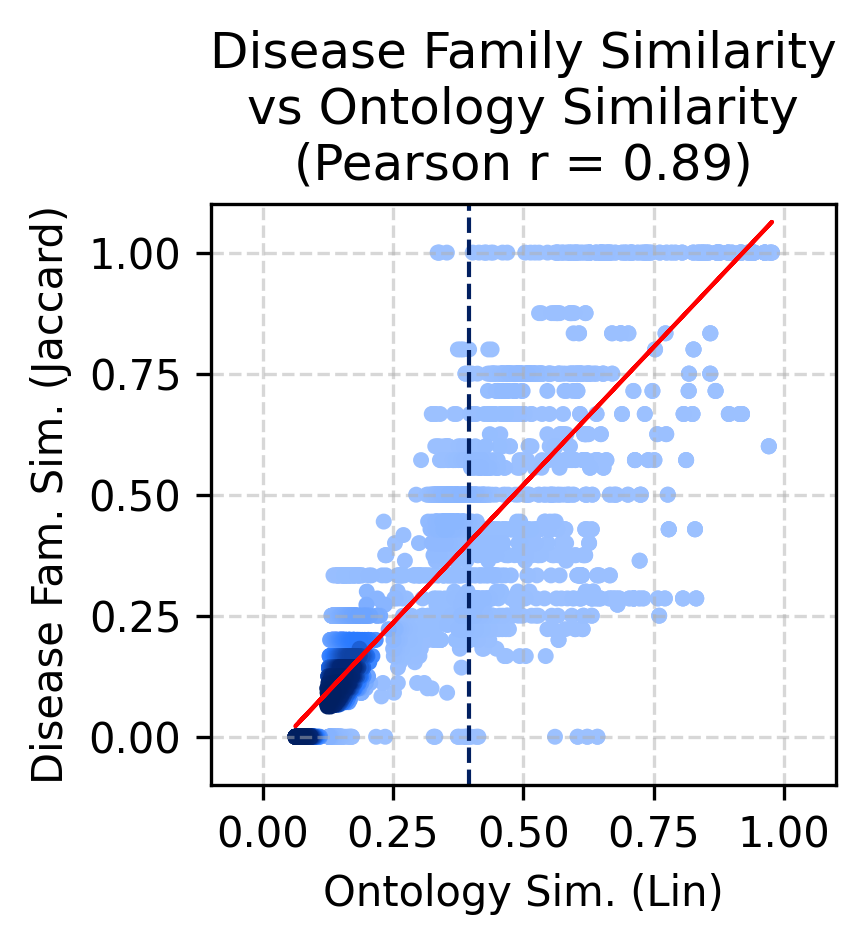

In [199]:
x = np.array(unr_ont_s +rel_ont_s)
y = np.array(unr_one_hot_s + rel_one_hot_s)

pearson_r, pearson_p = pearsonr(x, y)

pearson_r, pearson_p = pearsonr(x, y)

xy = np.vstack([x, y])
z = gaussian_kde(xy)(xy)

# Linear regression (least squares)
coef = np.polyfit(x, y, 1)
poly_fn = np.poly1d(coef)

idx = z.argsort()
x, y, z = x[idx], y[idx], z[idx]

plt.figure(figsize=(3, 3.25), dpi=300)
plt.scatter(x, y, c=z, s=8, zorder=1, cmap=custom_cmap)

plt.plot(x, poly_fn(x),  linewidth=1, color="red", zorder=3)

plt.xlabel("Ontology Sim. (Lin)")
plt.ylabel("Disease Fam. Sim. (Jaccard)")

plt.title(
    f"Disease Family Similarity\nvs Ontology Similarity\n(Pearson r = {pearson_r:.2f})"
)

plt.axvline(0.396, zorder=2, linestyle="--", linewidth=1, color="#011f60")

# plt.colorbar(label="Point density")
plt.grid(linestyle='--', alpha=0.5, zorder=-3)
plt.tight_layout()
plt.xlim(-0.1, 1.1)
plt.ylim(-0.1, 1.1)
plt.show()


(<Figure size 5400x1800 with 1 Axes>, <Axes: >)

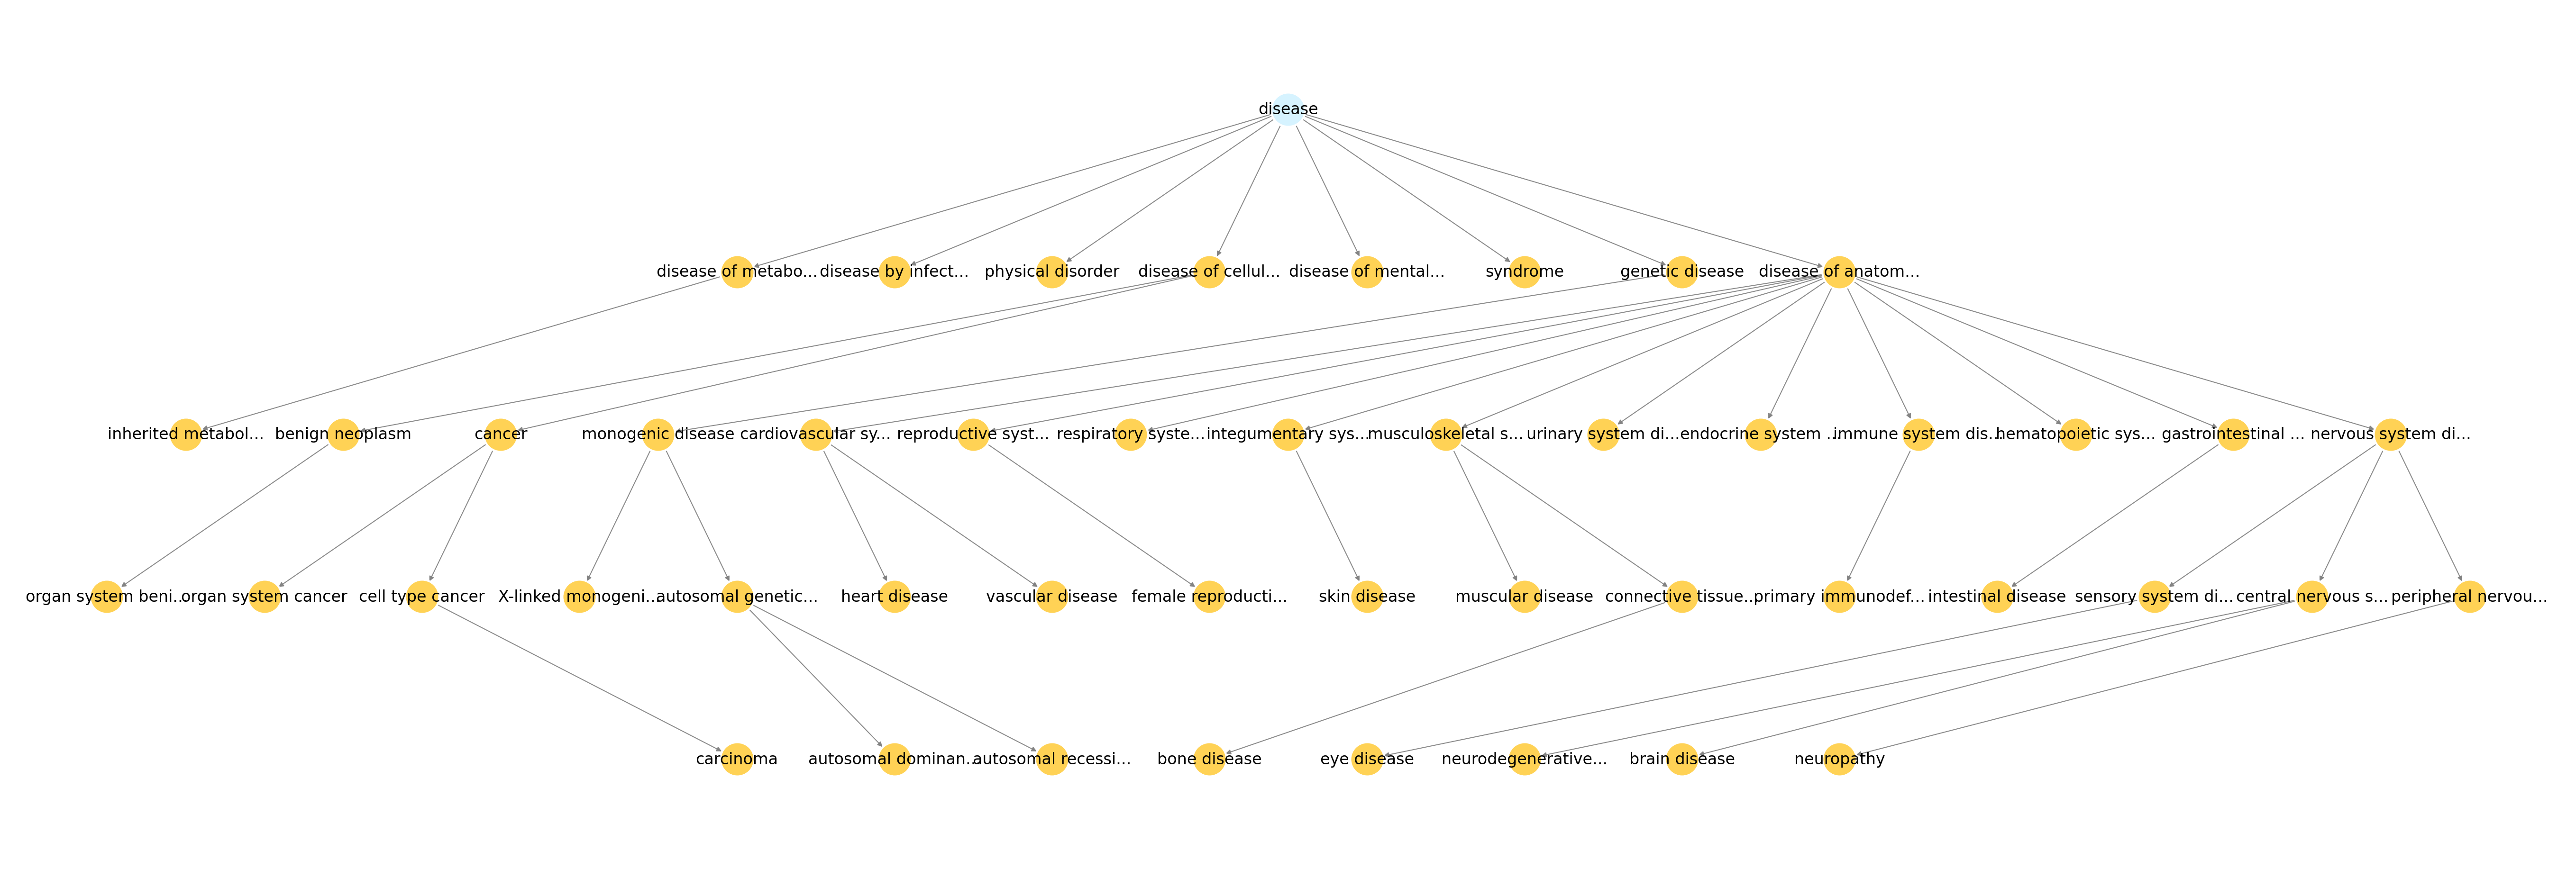

In [168]:
import networkx as nx
import matplotlib.pyplot as plt
import numpy as np
from collections import defaultdict

def _hierarchy_pos_from_levels(levels, level_gap=1.6, width_gap=1.6):
    """
    levels: dict[int, list[node]] with depth -> nodes
    Returns pos dict for plotting.
    """
    pos = {}
    for depth in sorted(levels):
        nodes = levels[depth]
        # center each level horizontally
        x0 = -0.5 * width_gap * (len(nodes) - 1)
        for i, n in enumerate(nodes):
            pos[n] = (x0 + i * width_gap, -depth * level_gap)
    return pos


def _compute_depths_dag(S: nx.DiGraph):
    """
    Depth from roots within S (nodes with in_degree==0 in S).
    Uses dynamic programming in topological order.
    """
    roots = [n for n in S.nodes() if S.in_degree(n) == 0]
    depth = {r: 0 for r in roots}

    for n in nx.topological_sort(S):
        if n not in depth:
            # if disconnected component without explicit root, start it
            depth[n] = 0
        for ch in S.successors(n):
            depth[ch] = max(depth.get(ch, 0), depth[n] + 1)

    levels = defaultdict(list)
    for n, d in depth.items():
        levels[d].append(n)
    return depth, levels


def plot_paths_from_roots_to_targets(
    G: nx.DiGraph,
    targets: list,
    id2name: dict | None = None,
    figsize=(18, 4),
    dpi=300,
    pad=1.0,
    level_gap=1.7,
    width_gap=1.7,
    title="Root→target paths",
):
    """
    Draw ONLY nodes/edges on paths connecting a 'father/root' disease node to each target.
    Assumes edges go parent -> child.

    - All nodes: white
    - Target nodes: orange
    """

    # --- pick "father/root" nodes in the full graph ---
    # Roots = nodes with no parents (in_degree==0). In DO this may be 'DOID:4' etc.
    roots = [n for n in G.nodes() if G.in_degree(n) == 0]
    if not roots:
        raise ValueError("No roots found (nodes with in_degree==0). Check edge direction.")

    # --- collect path nodes/edges for each target ---
    keep_nodes = set()
    keep_edges = set()

    for t in targets:
        if t not in G:
            continue

        # find candidate roots that can reach t
        reachable_roots = [r for r in roots if nx.has_path(G, r, t)]
        if not reachable_roots:
            # no root reaches this node (maybe edge direction reversed, or disconnected)
            continue

        # choose the "closest" root (minimal shortest-path length)
        best_root = min(reachable_roots, key=lambda r: nx.shortest_path_length(G, r, t))
        path = nx.shortest_path(G, best_root, t)

        keep_nodes.update(path)
        keep_edges.update(zip(path[:-1], path[1:]))

    if not keep_nodes:
        raise ValueError("No paths found for the provided targets (or targets missing in graph).")

    # --- induced subgraph for plotting ---
    S = G.subgraph(keep_nodes).copy()

    # --- hierarchical-ish layout without graphviz ---
    # We compute depths within S from S-roots to place nodes by level.
    _, levels = _compute_depths_dag(S)
    pos = _hierarchy_pos_from_levels(levels, level_gap=level_gap, width_gap=width_gap)

    # --- styling ---
    targets_in_S = [t for t in targets if t in S]
    other_nodes = [n for n in S.nodes() if n not in set(targets_in_S)]

    fig, ax = plt.subplots(figsize=figsize, dpi=dpi, constrained_layout=True)

    # edges (only along chosen paths)
    nx.draw_networkx_edges(
        S, pos,
        edgelist=list(keep_edges),
        arrows=True,
        arrowsize=5,
        width=0.5,
        style="-",
        alpha=0.9,
        ax=ax,
        edge_color="grey"
    )

    # nodes: all white
    nx.draw_networkx_nodes(
        S, pos,
        nodelist=other_nodes,
        node_color="#d6f3ff",
        edgecolors="white",
        # linewidths=0.6,
        # node_size=520,
        ax=ax
    )

    # targets: orange
    nx.draw_networkx_nodes(
        S, pos,
        nodelist=targets_in_S,
        node_color="#ffd255",  # orange
        edgecolors="white",
        # linewidths=0.8,
        # node_size=620,
        ax=ax
    )

    # labels (ID + optional name)
    if id2name is None:
        labels = {n: str(n) for n in S.nodes()}
    else:
        # labels = {n: f"{n}\n{id2name.get(n,'')}".strip() for n in S.nodes()}
        labels = dict()
        for n in S.nodes():
            name = id2name.get(n, "")
            if len(name)>20:
                name = name[:17] + "..."
            labels[n] = name

    # usually: label all is OK because this subgraph is cut down; if too dense, label only targets
    nx.draw_networkx_labels(S, pos, labels=labels, font_size=8, ax=ax)

    # bounds/padding
    xs = np.array([p[0] for p in pos.values()])
    ys = np.array([p[1] for p in pos.values()])
    ax.set_xlim(xs.min() - pad, xs.max() + pad)
    ax.set_ylim(ys.min() - pad, ys.max() + pad)
    ax.axis("off")

    ax.set_title(title)
    return fig, ax


# Example usage:
targets = ["DOID:0040044", "DOID:6727", ...]
plot_paths_from_roots_to_targets(do_graph, _class_nodes, id2name=doid_to_term,
                                 title="", figsize=(18, 6))
